# Global Conv1D Attention Challenger

Reproduces the evaluator architecture with causal convolutions, self-attention, spectral and known-future branches, ordered quantiles, five deterministic seeds and a challenger-only promotion gate.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "outputs").exists():
    ROOT = Path("Ai miroservices/modeling/project_operational_baseline").resolve()
OUT = ROOT / "outputs"
EVAL = OUT / "evaluator"
sns.set_theme(style="whitegrid")

## Architecture and claim boundary

- Input: 24 historical months; direct output: H1-H12.
- Two causal Conv1D layers use 3- and 6-month kernels.
- Two residual four-head self-attention blocks learn non-local dependence.
- Calendar, spectral, static and origin-known future features join after temporal pooling.
- P10/P50/P90 and cost-sensitive quantiles are ordered by construction.

Attention is descriptive, not a causal explanation. The network becomes champion only if locked pre-test evidence supports it.

In [2]:
summary=json.loads((EVAL/'evaluator_run_summary.json').read_text())
seed=pd.read_csv(EVAL/'neural_seed_stability.csv')
ablations=pd.read_csv(EVAL/'feature_group_ablations.csv')
display(pd.DataFrame([summary]).T)
display(seed.groupby('origin_month')[['WAPE','RMSE','epochs']].agg(['mean','std','min','max']))
display(ablations.sort_values('WAPE'))

,0
data_tier,GENERATED_OPERATIONAL_BASELINE
history_months,24
forecast_horizon_months,12
series_total,96
rm_pm_series,80
finished_good_series,16
selection_origins,"[2023-07-01, 2023-08-01, 2023-09-01, 2023-10-0..."
untouched_test_window,"[2025-01-01, 2025-12-01]"
neural_seeds,"[17, 42, 101, 303, 707]"
baseline_champion,EXTRA_TREES


WAPE                                       RMSE  \
                  mean       std       min       max         mean   
origin_month                                                        
2023-07-01    0.659721  0.342192  0.346494  1.235453  5277.406616   
2023-08-01    0.582033  0.196870  0.339171  0.877135  3420.449451   
2023-09-01    0.665791  0.320893  0.265310  1.160038  5929.928687   
2023-10-01    0.476895  0.204232  0.313625  0.800742  2583.609570   
2023-11-01    0.325378  0.113484  0.204936  0.510127  1070.798450   
2023-12-01    0.285565  0.023389  0.263471  0.317100   862.525964   
2024-01-01    0.234980  0.041926  0.180573  0.294478   711.309644   
2025-01-01    0.188677  0.021279  0.172267  0.224778   592.274585   

                                                     epochs                     
                      std          min           max   mean        std min max  
origin_month                                                                    
2023-07-01    6628.815237  1088.075806  16918.400391   53.8  14.324804  40  72  
2023-08-01    2278.425372   986.412537   7062.345215   47.4   7.765307  38  57  
2023-09-01    4458.695731   858.928345  12373.429688   64.6  18.187908  41  79  
2023-10-01    3014.357928   943.472168   7953.498047   47.0  10.793517  35  58  
2023-11-01     538.130400   586.336182   1967.160522   55.0  11.937336  43  75  
2023-12-01      43.672029   816.423462    920.113525   49.0  12.000000  37  65  
2024-01-01     150.779392   491.088501    914.158020   48.8   7.529940  36  54  
2025-01-01      81.886504   529.528687    725.923706   41.2   7.190271  30  50

,feature_group,split,model_name,rows,series,WAPE,MAE,RMSE,Bias,under_forecast_rate,selection_score
0,time_only,ablation,CONV1D_ATTENTION_GLOBAL,960,80,0.159613,163.939278,463.767630,0.010038,0.604167,0.164632
2,spectral,ablation,CONV1D_ATTENTION_GLOBAL,960,80,0.170357,174.974295,494.321842,0.104479,0.673958,0.222596
1,cyclic,ablation,CONV1D_ATTENTION_GLOBAL,960,80,0.176863,181.656440,514.024509,0.104066,0.662500,0.228896
4,full,ablation,CONV1D_ATTENTION_GLOBAL,960,80,0.209242,214.913372,652.071954,0.184533,0.743750,0.301508
3,known_future,ablation,CONV1D_ATTENTION_GLOBAL,960,80,0.281525,289.155978,913.366197,0.260741,0.768750,0.411895


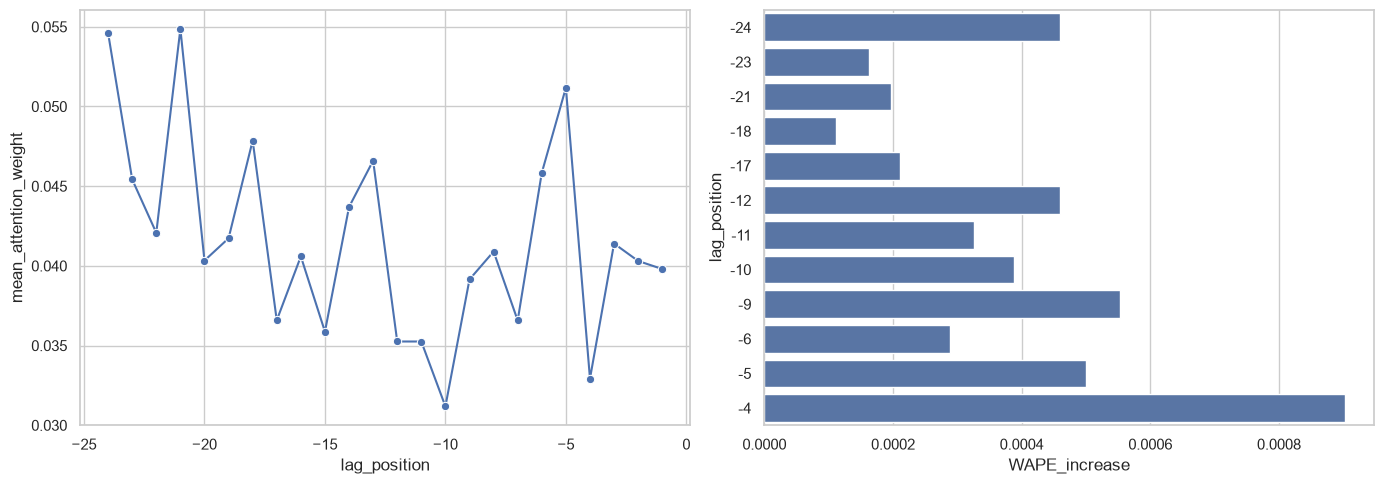

,feature_group,baseline_WAPE,permuted_WAPE,WAPE_increase,note
1,known_future,0.224778,0.863099,0.638321,"Held-out group permutation; association, not c..."
0,past_exogenous,0.224778,0.241071,0.016293,"Held-out group permutation; association, not c..."
2,spectral_summary,0.224778,0.217273,-0.007505,"Held-out group permutation; association, not c..."
3,static_features,0.224778,0.208733,-0.016045,"Held-out group permutation; association, not c..."


In [3]:
attention=pd.read_csv(EVAL/'attention_weights.csv')
occlusion=pd.read_csv(EVAL/'lag_occlusion_sensitivity.csv')
permutation=pd.read_csv(EVAL/'heldout_group_permutation.csv')
fig,axes=plt.subplots(1,2,figsize=(14,5))
sns.lineplot(data=attention,x='lag_position',y='mean_attention_weight',marker='o',ax=axes[0])
sns.barplot(data=occlusion.sort_values('WAPE_increase',ascending=False).head(12),x='WAPE_increase',y='lag_position',orient='h',ax=axes[1]); plt.tight_layout(); plt.show()
display(permutation.sort_values('WAPE_increase',ascending=False))

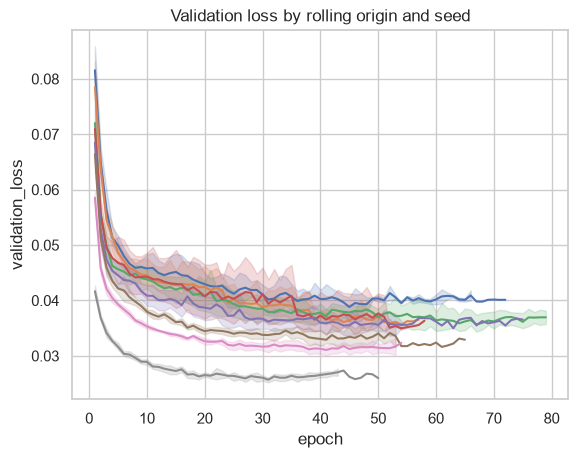

In [4]:
history=pd.read_csv(EVAL/'neural_training_history.csv')
sns.lineplot(data=history,x='epoch',y='validation_loss',hue='origin_month',legend=False); plt.title('Validation loss by rolling origin and seed'); plt.show()